In [2]:
%pip install fastcore
%pip install fastai

In [3]:
from fastcore.all import *
import time
from fastai.vision.all import *
import pandas as pd
import numpy as np
import os

In [4]:
import os
path = 'Augmented Dataset'
data_dir_list = os.listdir(path)
print(data_dir_list)
# remove the .DS_Store from the list if it exists
if '.DS_Store' in data_dir_list:
    data_dir_list.remove('.DS_Store')
print(data_dir_list)

['Glaucoma', 'Bulging eyes', 'Uveitis', 'Crossed_Eyes', 'Cataracts']
['Glaucoma', 'Bulging eyes', 'Uveitis', 'Crossed_Eyes', 'Cataracts']


In [5]:
get_items = get_image_files(path)

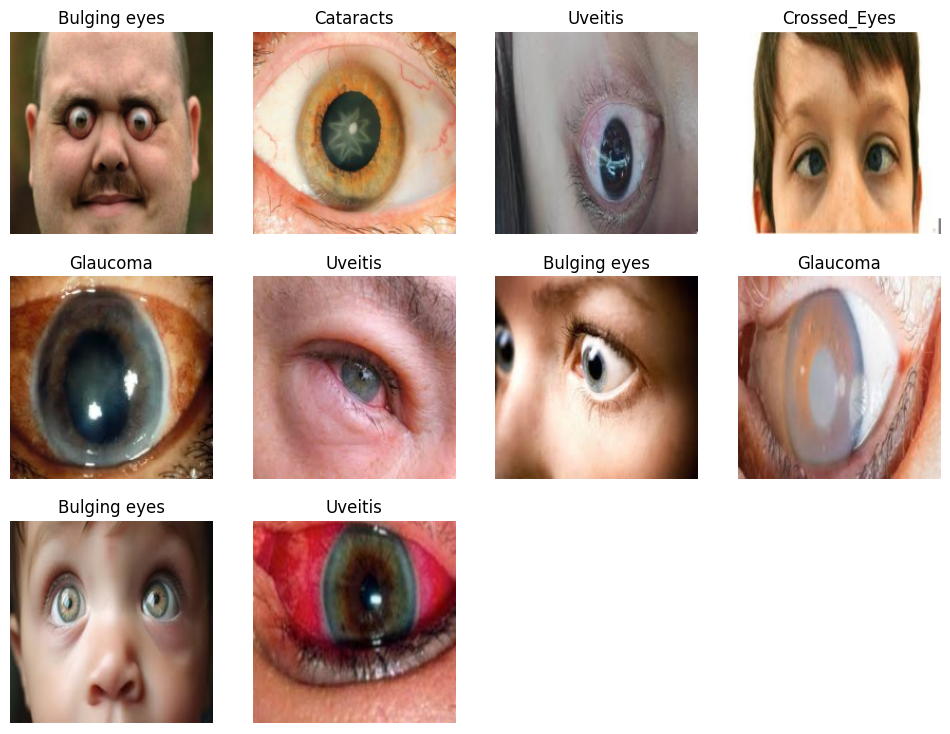

In [6]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path)

dls.show_batch(max_n=10)

In [7]:
dls.vocab

['Bulging eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']

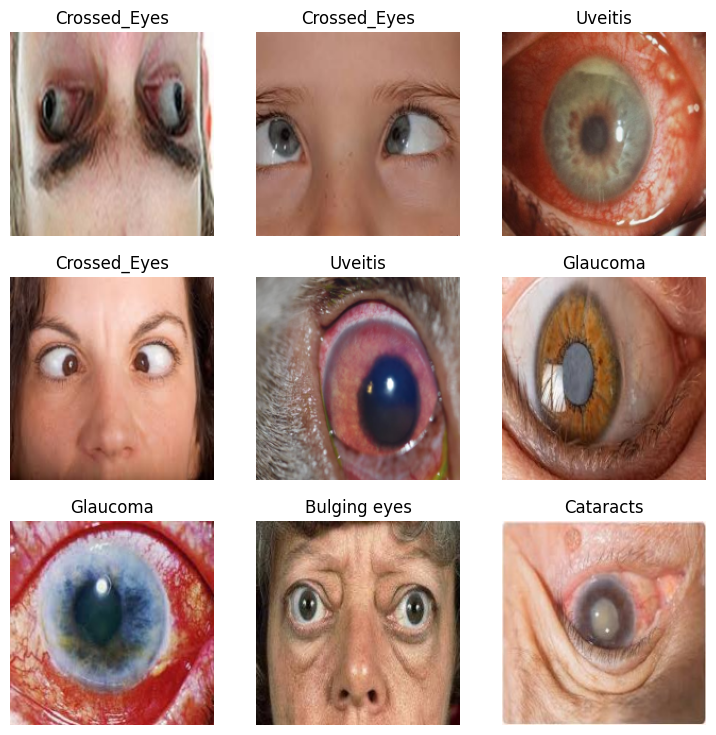

In [8]:
blocks = (ImageBlock, CategoryBlock),
get_items = get_image_files,
splitter = RandomSplitter(valid_pct=0.2, seed=42),
dls.show_batch()

In [9]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(50)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 393MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,2.065977,0.910968,0.632653,00:44


epoch,train_loss,valid_loss,accuracy,time
0,0.766934,0.689855,0.727891,01:00
1,0.577306,0.508800,0.795918,01:01
2,0.448276,0.393848,0.850340,01:01
3,0.344773,0.326963,0.870748,01:00
4,0.264382,0.306800,0.884354,01:01
5,0.208958,0.307267,0.891156,01:00
6,0.169729,0.296189,0.897959,01:01
7,0.139420,0.299907,0.891156,01:01
8,0.115065,0.293427,0.911565,01:01
9,0.093900,0.295492,0.911565,00:59


In [10]:
learn.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 192 x 192)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 96 x 96   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 48 x 48   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

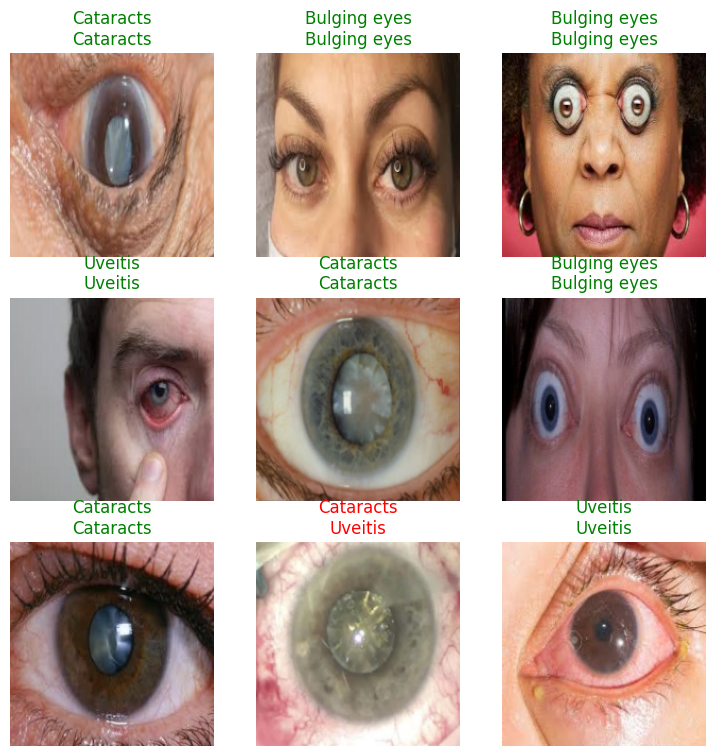

In [11]:
learn.show_results()

<div></div>

SuggestedLRs(valley=0.0004786300996784121)

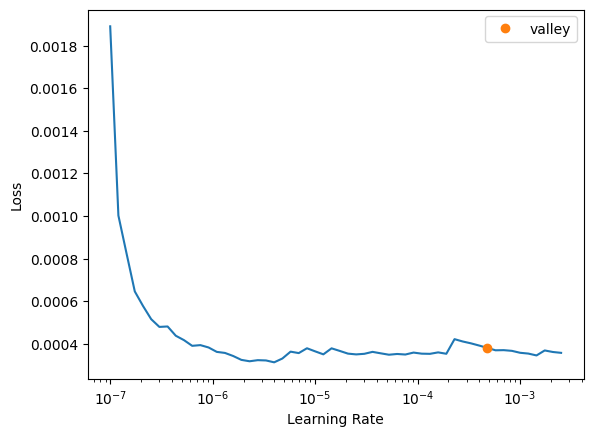

In [12]:
learn.lr_find()

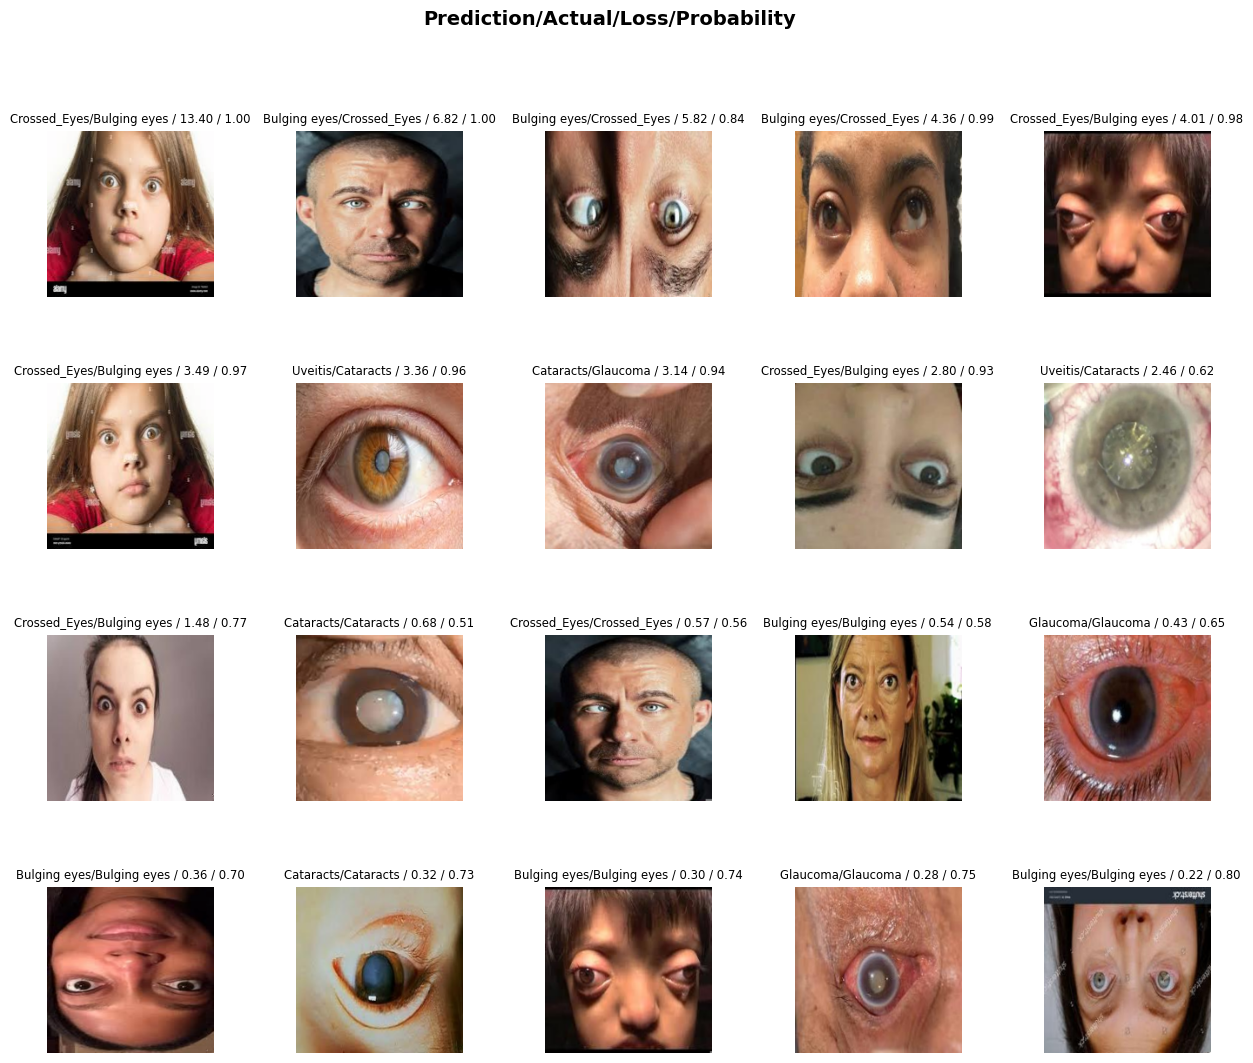

In [13]:
import matplotlib.pyplot as plt

# Set font size for the entire plot
plt.rcParams['font.size'] = 7

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(20)
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()